# **TP 4 : Computational Statistics**

__Abel Verley__

## **Exercice 1 :**

### 1.A : Adaptative Metropolis-Hastings within Gibbs sampler 

>**Question 1:** Le noyau de transition peut être simulé par l'algorithme Random Scan Gibbs Sampler qui itère les instructions suivantes : 
\begin{equation}
    \begin{cases}
        \text{Séléctionner } i \in \{1,2\} \text{ de manière aléatoire et uniforme} \\
        \text{Si } i = 1 \text{, échantillonner : } x' \sim \pi(\cdot | y) \text{ et } y' = y \\
        \text{Si } i = 2 \text{, échantillonner : } y' \sim \pi(\cdot | x) \text{ et } x' = x \\
        (x,y) \gets (x',y')
    \end{cases}
\end{equation}
Le nom de l'algorithme est alors justifié par le fait qu'il sagit de la même procédure qu'un échantillonneur de Gibbs à l'exception que la coordonnée mise à jour n'est pas alternée mais choisie aléatoirement. L'algorithme Metropolis-Hastings peut être utilisé pour échantillonner les distributions conditionnelles : 
\begin{equation}
    \begin{cases}
        \pi(y | x) \propto \exp(y^2(\frac{x^2}{2a^2}-\frac{y^2}{4}-1))\\
        \pi(x |y) \propto \exp(\frac{x^2}{a^2}(\frac{y^2}{2}-\frac{x^2}{4a^2}-1))
    \end{cases}
\end{equation}
Notons qu'il n'est pas nécéssaire de connaitre la constante de normalisation (dépendant de la variable sur laquelle on conditionne) pour échantillonner par Metropolis-Hastings.


>**Question 2 :** On implémente, par la méthode de Metropolis-Hastings, les noyaux de transition $P_1$ et $P_2$, puis $P$.

In [1]:
import jax 
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.scipy.stats import multivariate_normal
from pandas.plotting import autocorrelation_plot

key = jr.PRNGKey(0)

In [2]:
def ll_comp(x, y, a): 
    return -x**2/a**2-y**2-(x**2/a**2-y**2)**2/4

In [3]:
def sampleP1(key, x, y, a, var1): 
    subkey1, subkey2 = jr.split(key)
    x_prop = x + jnp.sqrt(var1)*jr.normal(subkey1)
    ll = ll_comp(x,y,a)
    ll_prop = ll_comp(x_prop, y, a)
    u = jr.uniform(subkey2)
    # acc = 1 iif proposal accepted, else acc = 0
    x, y, acc = jax.lax.cond(
        jnp.log(u)<ll_prop-ll, 
        lambda : (x_prop,y,1), 
        lambda : (x, y, 0)
    )
    return x, y, acc, 1

In [4]:
def sampleP2(key, x, y, a, var2): 
    subkey1, subkey2 = jr.split(key)
    y_prop = y + jnp.sqrt(var2)*jr.normal(subkey1)
    ll = ll_comp(x,y,a)
    ll_prop = ll_comp(x, y_prop, a)
    u = jr.uniform(subkey2)
    x, y, acc = jax.lax.cond(
        jnp.log(u)<ll_prop-ll, 
        lambda : (x,y_prop,1), 
        lambda : (x, y, 0)
    )
    return x, y, acc, 2

In [5]:
def sampleP(key, x, y, a, var1, var2):
    # Run either P1 or P2 with proba .5
    subkey1, subkey2 = jr.split(key)
    u = jr.uniform(subkey1)
    cond = u < .5
    x,y, acc, updated_var = jax.lax.cond(
        cond, 
        lambda  : sampleP1(subkey2, x, y, a, var1),
        lambda  : sampleP2(subkey2, x, y, a, var2)
    )

    return x,y, acc, updated_var

In [6]:

def MwRSG_sampler(key, x0, y0, a, var1, var2, n_iter, window_size=100): 
    
    def gibbs_step(carry, key):
        # Unpack carry
        x, y = carry["x"], carry["y"]
        iteration = carry["iteration"]
        # Buffers store acceptation during last window_size iterations
        buf1, buf2 = carry["buffer1"], carry["buffer2"]
        # Indices to know where to write in the  buffers
        idx1, idx2 = carry["idx1"], carry["idx2"]

        # Sample
        x, y, acc, updated_var = sampleP(key, x, y, a, var1, var2)


        buf1, idx1, buf2, idx2 = jax.lax.cond(
            updated_var == 1,
            lambda: (buf1.at[idx1 % window_size].set(acc), idx1 + 1, buf2, idx2),
            lambda: (buf1, idx1, buf2.at[idx2 % window_size].set(acc), idx2 + 1)
        )


        acc_rate1 = jnp.sum(buf1) / jnp.minimum(idx1, window_size)
        acc_rate2 = jnp.sum(buf2) / jnp.minimum(idx2, window_size)

        new_carry = {
            "x": x, "y": y, "iteration": iteration + 1,
            "buffer1": buf1, "idx1": idx1,
            "buffer2": buf2, "idx2": idx2
        }
        
        output = {
            "x": x, "y": y,
            "acc_rate1": jnp.nan_to_num(acc_rate1), # Safety against div by zero
            "acc_rate2": jnp.nan_to_num(acc_rate2)
        }
        return new_carry, output
    
    init = {
        "x": x0, "y": y0, "iteration": 0,
        "buffer1": jnp.zeros(window_size), "idx1": 0,
        "buffer2": jnp.zeros(window_size), "idx2": 0
    }
        
    keys = jax.random.split(key, n_iter)
    carry, outputs = jax.lax.scan(gibbs_step, init, keys)
    return carry["x"], carry["y"], outputs

In [7]:
# Test the algorithm with provided values

a = 10
var1 = 3.
var2 = 3.

x0 = 0.
y0 = 0.

n_iter = 2000

key, subkey = jr.split(key)

x, y, outputs = MwRSG_sampler(subkey, x0, y0, a, var1, var2, n_iter)


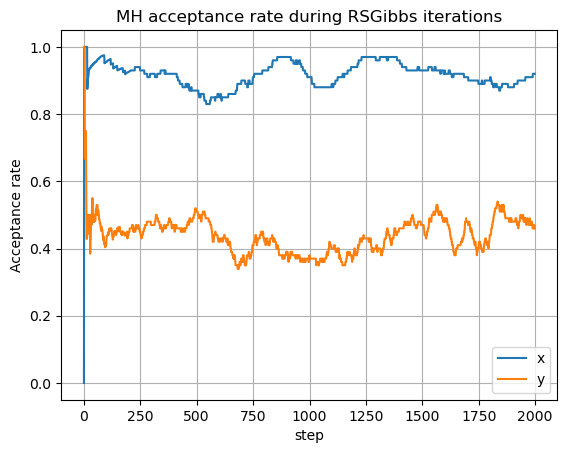

In [8]:
plt.plot(outputs["acc_rate1"], label = "x")
plt.plot(outputs["acc_rate2"], label = "y")
plt.xlabel("step")
plt.ylabel("Acceptance rate")
plt.legend()
plt.grid()
plt.title("MH acceptance rate during RSGibbs iterations")
plt.show()

In [9]:
def plot_MC_with_contour(x,y,a, ax, title = None, x_lim = None, y_lim = None):
    x_min, x_max = (x_lim[0], x_lim[1]) if x_lim is not None else (-15, 15)
    y_min, y_max = (y_lim[0], y_lim[1]) if y_lim is not None else (-2, 2)

    x_dots = jnp.linspace(x_min,x_max,200)
    y_dots = jnp.linspace(y_min, y_max, 200)
    X,Y = jnp.meshgrid(x_dots, y_dots)
    Z = jax.vmap(lambda x,y : ll_comp(x,y,a))(X,Y)
    ax.contourf(X,Y, Z, levels = 20)
    ax.scatter(x,y, c = "red", s = 0.5)
    ax.grid()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if title is not None:
        ax.set_title(title)

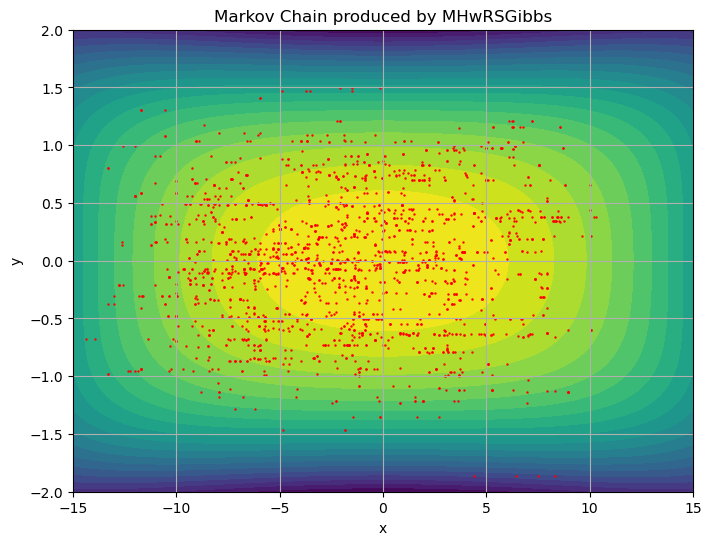

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_MC_with_contour(outputs["x"], outputs["y"], a, ax,  title = "Markov Chain produced by MHwRSGibbs")
plt.show()

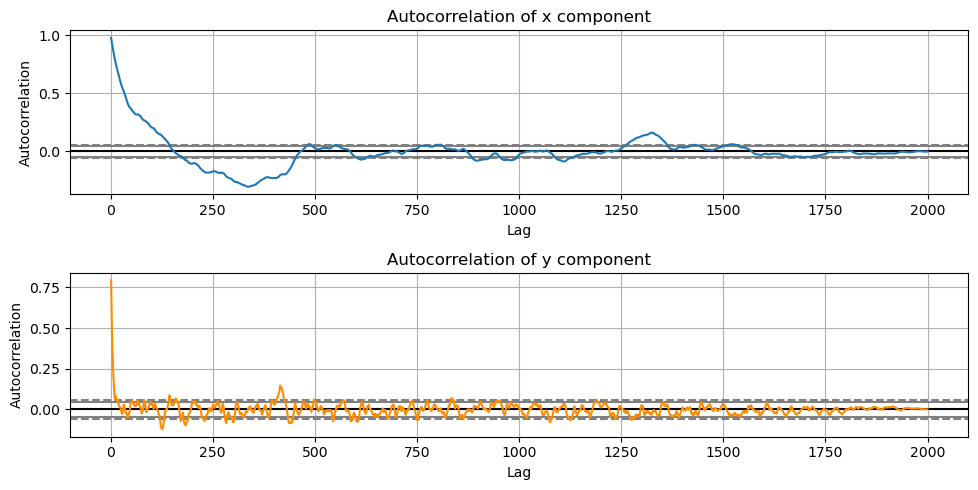

In [11]:
fig, axs = plt.subplots(2, 1, figsize = (10, 5))
autocorrelation_plot(outputs["x"], axs[0])
axs[0].set_title("Autocorrelation of x component")
autocorrelation_plot(outputs["y"], axs[1],c='darkorange')
axs[1].set_title("Autocorrelation of y component")
fig.tight_layout()

> Avec les paramètres choisis, on remarque que les échantillons générés semblent représentatifs de la distribution cible. On remarque tout de même des points dans des zones de faible densité. En revarche, les taux d'acceptation de Metropolis-Hastings sont anormalement hauts ; particulièrement pour la chaine $x$ qui est de l'ordre de $90\%$ mais aussi pour la chaine $x$ qui est de l'ordre de $50\%$. Par ailleurs on voit dans les diagrames d'autocorrelation que les temps de mixage, surtout pour la coordonnée x sont très élevés. 

> **Question 4 :** Pour améliorer les performances de notre méthode d'échantillonnage on peut fine-tunner les paremtères ou bien essayer des méthodes d'échantillonnage plus efficaces : Adaptative Metropolis-Hastings. 

### 1.B : Adaptive Metropolis-Hastings within Gibbs sampler

> **Question 1 :** On implémente la méthode de Metropolis-Hastings within Gibbs avec et sans adaptation de variance.

In [12]:
# Function to perform 1 transition of a MH kernel with ll given
def gibbs_transition(key, ll_fun, xs, vars):
    # Performs the MH transition on one signle coordinate 
    def MH_coordinate(i, carry):
        xs = carry["xs"]
        keys = carry["keys"]
        accs = carry["accs"]

        # Make proposal
        subkey1, subkey2 = jr.split(keys[i])
        xs_prop = xs.at[i].set(xs[i]+jnp.sqrt(vars[i])*jr.normal(subkey1))
        
        # Accept reject
        ll = ll_fun(xs)
        ll_prop = ll_fun(xs_prop)
        u = jr.uniform(subkey2)
        xs, acc = jax.lax.cond(
            jnp.log(u)<ll_prop-ll, 
            lambda : (xs_prop, 1),
            lambda : (xs, 0)
        ) 

        carry = {
            "xs" : xs,
            "keys" : keys,
            "accs" : accs.at[i].set(acc)
        }
        return carry
    # Iterate over all coordinate with fori loop
    d = xs.shape[0]
    init = {
        "xs": xs, 
        "keys" : jr.split(key, d),
        "accs" : jnp.zeros(d)
    }
    carry = jax.lax.fori_loop(0, d, MH_coordinate, init)
    return carry["xs"], carry["accs"]




# Function for updating the relevent variables every 50 iteration
def update_vars(vars, acc_rates, delta):
    # The following operation is equivalent to modifying l 
    f = lambda var, acc_rate : jax.lax.cond(
        acc_rate > 0.234, 
        lambda : jnp.exp(0.5*jnp.log(var) + delta)**2, 
        lambda : jnp.exp(0.5*jnp.log(var) - delta)**2
    )
    vars = jax.vmap(f)(vars, acc_rates)
    return vars

def adaptative_MHwG_sampler(key, xs0, ll, vars, n_iter, adaptative = True, window_size = 100):
    

    # Core function to define one step of the Gibbs algorithm a
    def gibbs_step(carry, key):
        # Unwrap carry
        xs = carry["xs"]
        iteration = carry["iteration"]
        vars = carry["vars"]
        # Buffers store acceptation during last window_size iterations
        bufs = carry["buffers"]


        # Apply Gibbs sampling
        xs, accs = gibbs_transition(key, ll, xs, vars)

        # Update buffers
        buf_idx = iteration % window_size
        bufs = bufs.at[:, buf_idx].set(accs)

        current_window_fill = jnp.minimum(iteration, window_size)
        acc_rates = jnp.sum(bufs, axis=1) / current_window_fill


        # Modify variances every 50 iteration when acceptation is True
        update_cond = adaptative and (iteration%50 == 0)
        j = iteration//50
        delta = jnp.minimum(0.05, 1/jnp.sqrt(j))
        vars = jax.lax.cond(
            update_cond, 
            lambda : update_vars(vars, acc_rates, delta),
            lambda : vars
        )

        # Make output
        carry = {
            "xs" : xs, 
            "iteration" : iteration + 1,
            "vars": vars,
            "buffers" : bufs
        }

        output = {
            "xs" : xs,  
            "vars" : vars, 
            "acc_rates" : acc_rates
        }
        return carry, output

    d = xs0.shape[0]
    # Perform the algorithm with jax.lax.scan
    init = {
        "xs" : xs0, 
        "iteration": 1, 
        "vars" : vars,  
        "buffers" : jnp.zeros(shape = (d, window_size))
    }
    keys = jr.split(key, n_iter)
    carry, outputs = jax.lax.scan(gibbs_step, init, keys)
    return carry["xs"], outputs

In [13]:
# Test the algorithm with provided values

a = 10
ll = lambda x : ll_comp(x[0], x[1], a)
vars = jnp.array([3.,3.])

xs0 = jnp.array([3.,3.])

n_iter = 2000

key, subkey1, subkey2 = jr.split(key, 3)

xs, outputs = adaptative_MHwG_sampler(subkey1, xs0, ll, vars, n_iter, adaptative=False)
xs_adapt, outputs_adapt = adaptative_MHwG_sampler(subkey2, xs0, ll, vars, n_iter, adaptative=True)

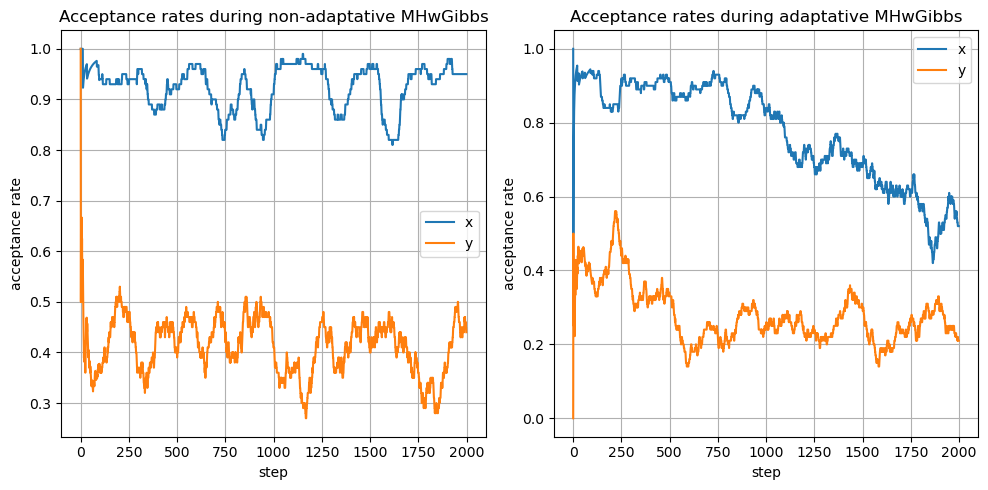

In [14]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(outputs["acc_rates"][:,0], label = "x")
ax[0].plot(outputs["acc_rates"][:,1], label = "y")
ax[0].set_xlabel("step")
ax[0].set_ylabel("acceptance rate")
ax[0].grid()
ax[0].legend()
ax[0].set_title("Acceptance rates during non-adaptative MHwGibbs")

ax[1].plot(outputs_adapt["acc_rates"][:,0], label = "x")
ax[1].plot(outputs_adapt["acc_rates"][:,1], label = "y")
ax[1].set_xlabel("step")
ax[1].set_ylabel("acceptance rate")
ax[1].grid()
ax[1].legend()
ax[1].set_title("Acceptance rates during adaptative MHwGibbs")

fig.tight_layout()

In [15]:
outputs["xs"].shape

(2000, 2)

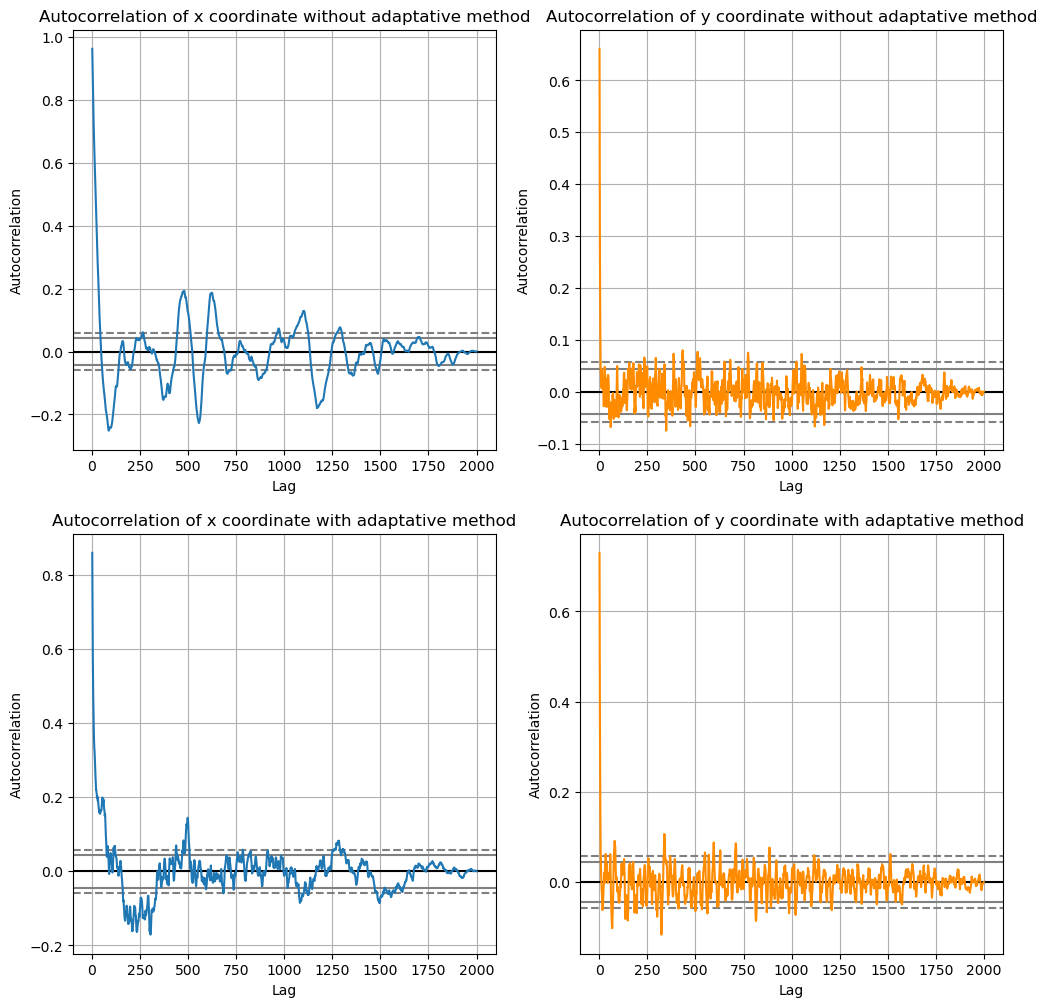

In [16]:
fig, axs = plt.subplots(2, 2, figsize = (12, 12))
autocorrelation_plot(outputs["xs"][:,0], axs[0,0])
axs[0,0].set_title("Autocorrelation of x coordinate without adaptative method")

autocorrelation_plot(outputs_adapt["xs"][:,0], axs[1,0])
axs[1,0].set_title("Autocorrelation of x coordinate with adaptative method")

autocorrelation_plot(outputs["xs"][:,1], axs[0,1], c = "darkorange")
axs[0,1].set_title("Autocorrelation of y coordinate without adaptative method")

autocorrelation_plot(outputs_adapt["xs"][:,1], axs[1,1], c = "darkorange")
axs[1,1].set_title("Autocorrelation of y coordinate with adaptative method")


fig.tight_layout
plt.show()


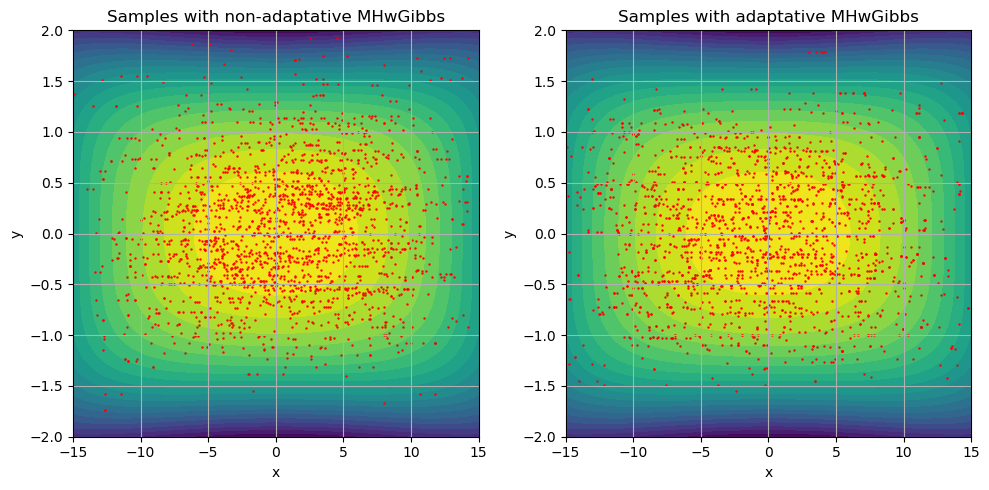

In [17]:
fig, axs = plt.subplots(1,2, figsize = (10, 5))
plot_MC_with_contour(outputs["xs"][:,0], outputs["xs"][:,1], a, axs[0], title = "Samples with non-adaptative MHwGibbs")
plot_MC_with_contour(outputs_adapt["xs"][:,0], outputs_adapt["xs"][:,1], a, axs[1], title = "Samples with adaptative MHwGibbs")
fig.tight_layout()


> On constate sur le diagrame d'autocorrelation que, en particulier pour la coordonnée x, la méthode adaptative fournie des temps de mixage plus faibles. De plus, elle ne semble pas explorer des zones de trop faible densité. En revanche, avec les paramètres fournis on remarque que le taux d'acceptation de la chaine $x$ n'a pas convergé vers $0.234$ après $2000$ itérations, il pourrait être préférable d'avoir une adaptation plus drastique de la variance. 

>**Question 2 :** On applique maintenant les méthodes adaptative à la distribution en forme de banane. A nouveau on voit bien le taux d'acceptation baisser dans le cas de la méthode adpatative, en revanche les temps de mixages semblent similaires pour les deux méthodes.  

In [18]:
B = 0.4
d = 5

def ll_banane(xs, B=0.4):
    term0 = -0.5 * (xs[0]**2) 
    term1 = -0.5 * (xs[1] + B * xs[0]**2 - B)**2 
    term_rest = -0.5 * jnp.sum(xs[2:]**2)
    
    return term0 + term1 + term_rest

vars = jnp.ones(d)
xs0 = jnp.zeros(d)
n_iter = 5000
key, subkey1, subkey2 = jr.split(key, 3)
xs, outputs = adaptative_MHwG_sampler(subkey1, xs0, ll_banane, vars, n_iter, adaptative=False)
xs_adapt, outputs_adapt = adaptative_MHwG_sampler(subkey2, xs0, ll_banane, vars, n_iter, adaptative=True)

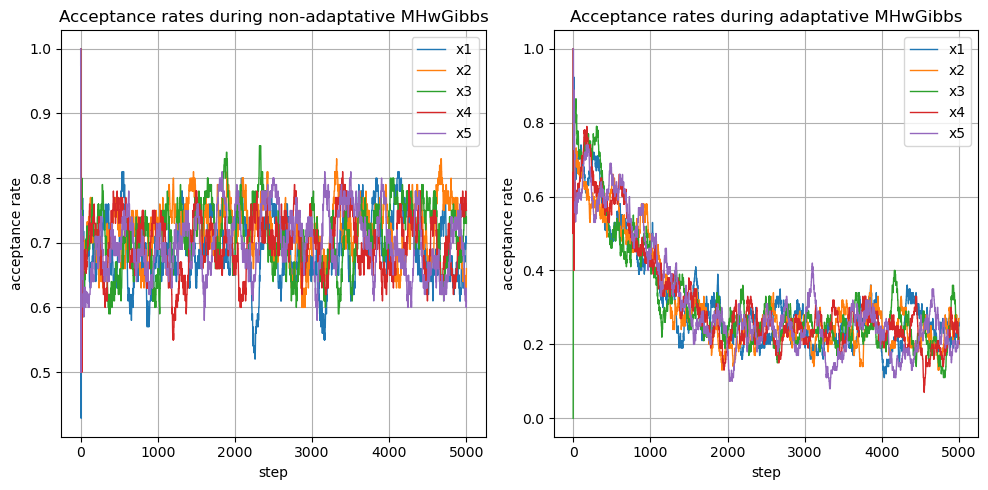

In [19]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(outputs["acc_rates"][:,0], label = "x1", linewidth=1)
ax[0].plot(outputs["acc_rates"][:,1], label = "x2", linewidth=1)
ax[0].plot(outputs["acc_rates"][:,2], label = "x3", linewidth=1)
ax[0].plot(outputs["acc_rates"][:,3], label = "x4", linewidth=1)
ax[0].plot(outputs["acc_rates"][:,4], label = "x5", linewidth=1)
ax[0].set_xlabel("step")
ax[0].set_ylabel("acceptance rate")
ax[0].grid()
ax[0].legend()
ax[0].set_title("Acceptance rates during non-adaptative MHwGibbs")

ax[1].plot(outputs_adapt["acc_rates"][:,0], label = "x1", linewidth=1)
ax[1].plot(outputs_adapt["acc_rates"][:,1], label = "x2", linewidth=1)
ax[1].plot(outputs_adapt["acc_rates"][:,2], label = "x3", linewidth=1)
ax[1].plot(outputs_adapt["acc_rates"][:,3], label = "x4", linewidth=1)
ax[1].plot(outputs_adapt["acc_rates"][:,4], label = "x5", linewidth=1)
ax[1].set_xlabel("step")
ax[1].set_ylabel("acceptance rate")
ax[1].grid()
ax[1].legend()
ax[1].set_title("Acceptance rates during adaptative MHwGibbs")

fig.tight_layout()

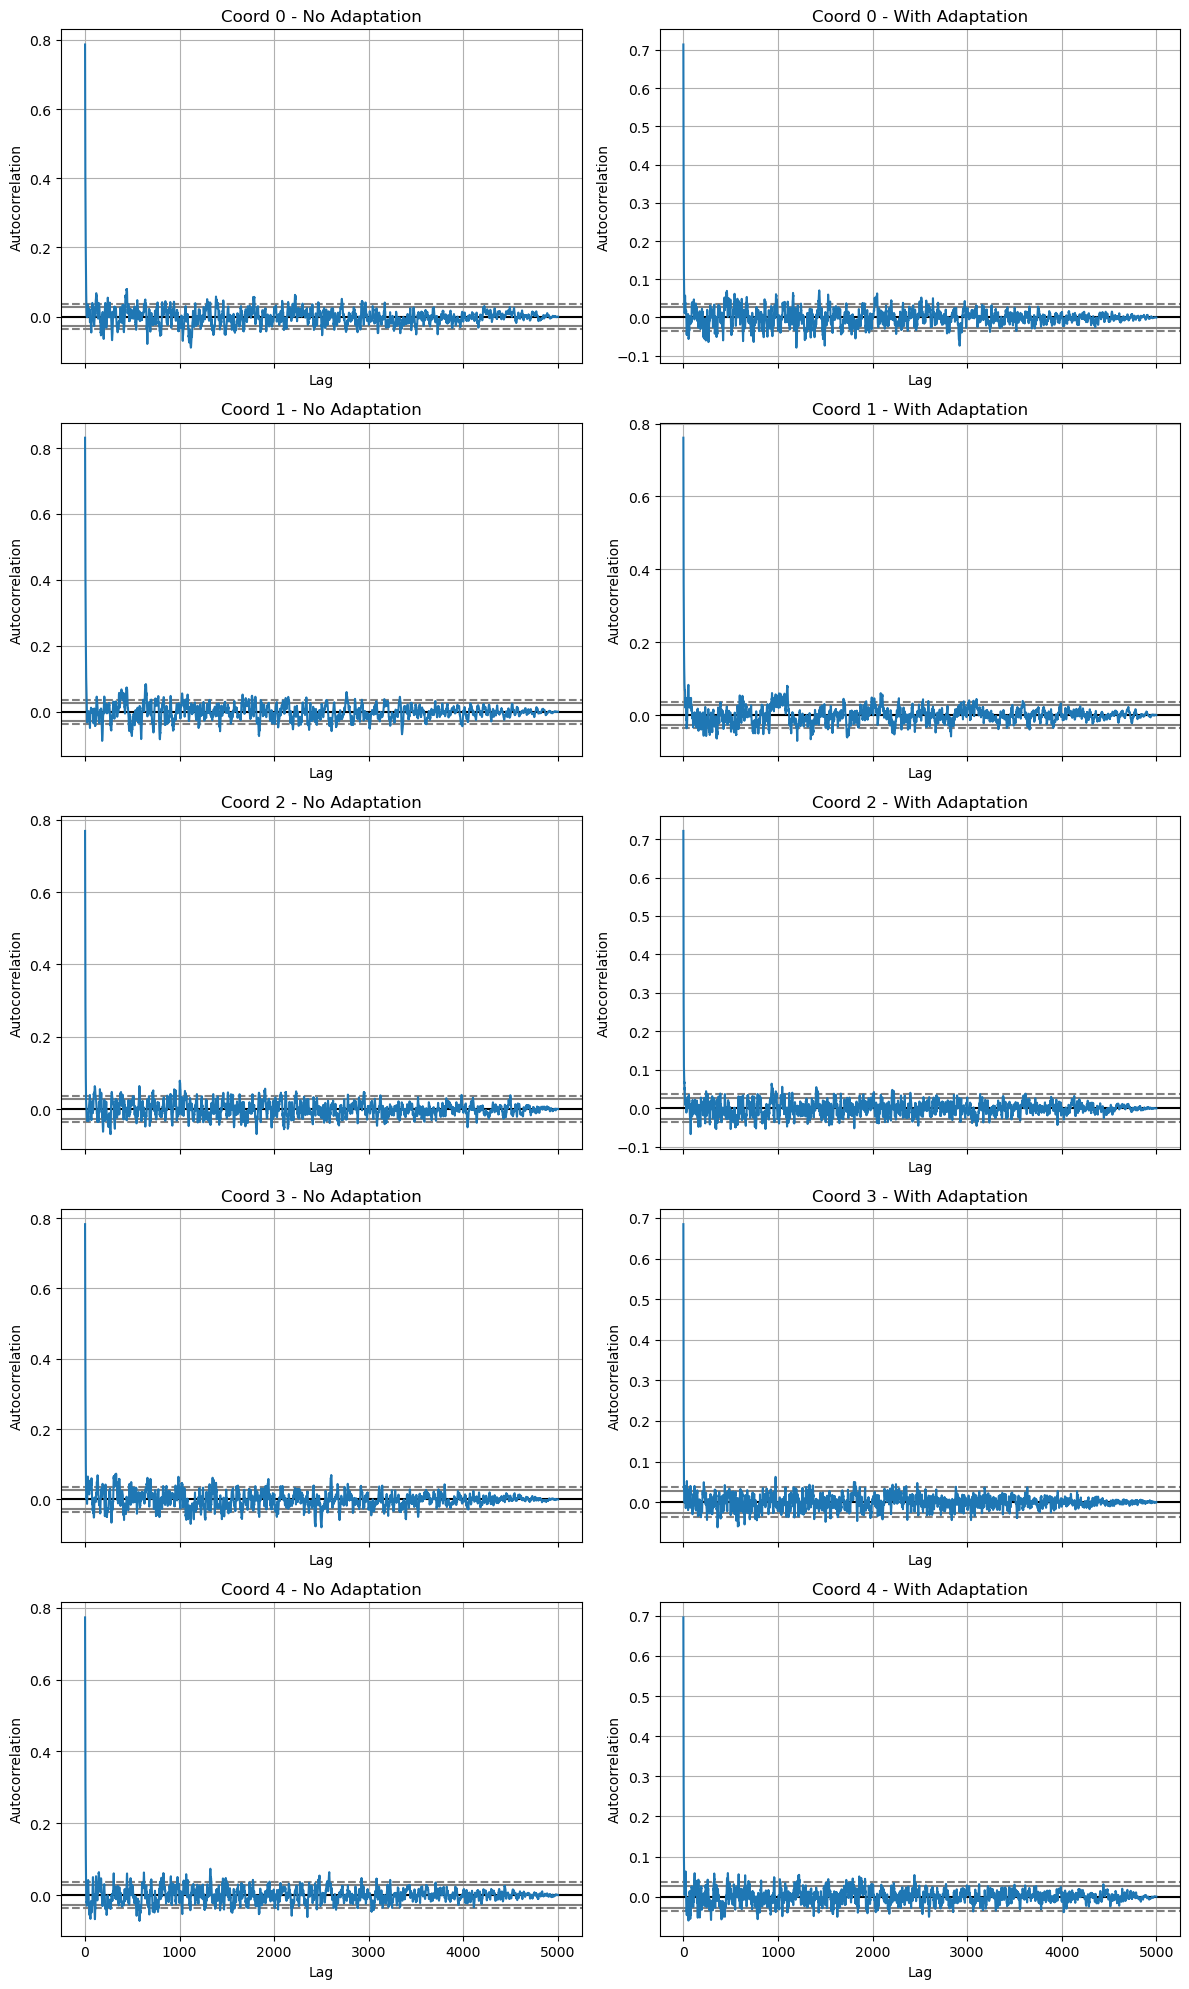

In [20]:

fig, axs = plt.subplots(d, 2, figsize=(12, 4 * d), sharex=True)

for i in range(d):
    autocorrelation_plot(outputs["xs"][:, i], axs[i, 0])
    axs[i, 0].set_title(f"Coord {i} - No Adaptation")
    axs[i, 0].set_ylabel("Autocorrelation")

    autocorrelation_plot(outputs_adapt["xs"][:, i], axs[i, 1])
    axs[i, 1].set_title(f"Coord {i} - With Adaptation")

for j in range(2):
    axs[d-1, j].set_xlabel("Lag")

fig.tight_layout()
plt.show()

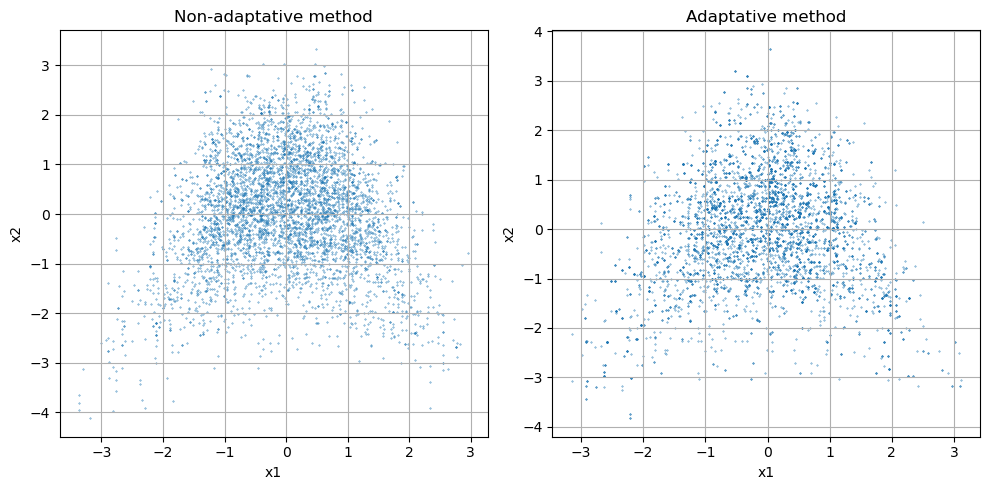

In [21]:
fig, axs = plt.subplots(1,2, figsize = (10, 5))
axs[0].scatter(outputs["xs"][:,0], outputs["xs"][:, 1], s = 0.1)
axs[0].set_xlabel("x1")
axs[0].set_ylabel("x2")
axs[0].grid()
axs[0].set_title("Non-adaptative method")
axs[1].scatter(outputs_adapt["xs"][:,0], outputs_adapt["xs"][:, 1], s= 0.1)
axs[1].set_xlabel("x1")
axs[1].set_ylabel("x2")
axs[1].grid()
axs[1].set_title("Adaptative method")
fig.tight_layout()

## **Exercice 2 :**

### 2.A : A toy example

>**Question 1 :** On implémente les fonctions $\pi$ et $\log \pi$ :

In [22]:
mus = jnp.array([
    [2.18, 5.76],
    [8.67, 9.59],
    [4.24, 8.48],
    [8.41, 1.68],
    [3.93, 8.82],
    [3.25, 3.47],
    [1.70, 0.50],
    [4.59, 5.60],
    [6.91, 5.81],
    [6.87, 5.40],
    [5.41, 2.65],
    [2.70, 7.88],
    [4.98, 3.70],
    [1.14, 2.39],
    [8.33, 9.50],
    [4.93, 1.50],
    [1.83, 0.09],
    [2.26, 0.31],
    [5.54, 6.86],
    [1.69, 8.11]
])

cov = jnp.diag(jnp.array([0.01, 0.01]))
w = 0.05

def pi(x) : 
    return jnp.sum(jax.vmap(lambda mu : w*multivariate_normal.pdf(x, mu, cov))(mus))

def log_pi(x):
    return jnp.log(pi(x))

>**Question 2 :** On implémente la méthode de Metropolis Hastings Symetric Random Walk : 

In [23]:
def MHSRW(key, x0, var, n_iter):

    def MH_step(carry, key):
        # Unwrap carry
        x, n_acc = carry["x"], carry["n_acc"]
        

        # Make proposal
        subkey1, subkey2 = jr.split(key)
        x_prop = x+ jnp.sqrt(var)*jr.normal(subkey1, shape= (2,))

        # Accept reject
        ll = log_pi(x)
        ll_prop = log_pi(x_prop)
        u = jr.uniform(subkey2)
        x, n_acc = jax.lax.cond(
            jnp.log(u) < ll_prop - ll,
            lambda : (x_prop, n_acc+1),
            lambda : (x, n_acc)
        )

        carry = {
            "x": x,  
            "n_acc" : n_acc
        }


        return carry, x
    
    init = {
        'x' : x0, 
        'n_acc' : 0
    }
    keys = jr.split(key, n_iter)
    carry, outputs = jax.lax.scan(MH_step,init, keys)
    print(f"Metropolis Hastings executed with acceptance rate : {carry['n_acc']/n_iter:.2%}")
    return outputs



>**Question 3 :** On échantillonne par la fonction ci-dessus. On remarque alors que la chaine de Markov produite reste bloquée dans un seul mode de la distribution cible. 

In [24]:
x0 = jnp.array([5.,5.])
var = 0.1
n_iter = 2000
key, subkey = jr.split(key)
xs = MHSRW(subkey, x0, var, n_iter)

Metropolis Hastings executed with acceptance rate : 14.05%


In [25]:
def plot_MC_with_contour2(x, y, ax, title=None, x_lim=None, y_lim=None):
    x_min, x_max = (x_lim[0], x_lim[1]) if x_lim is not None else (0, 10)
    y_min, y_max = (y_lim[0], y_lim[1]) if y_lim is not None else (0, 10)

    x_dots = jnp.linspace(x_min, x_max, 200)
    y_dots = jnp.linspace(y_min, y_max, 200)
    X, Y = jnp.meshgrid(x_dots, y_dots)
    
    points = jnp.c_[X.ravel(), Y.ravel()]
    Z_flat = jax.vmap(pi)(points)
    Z = Z_flat.reshape(X.shape)
    
    ax.contourf(X, Y, Z, levels=20)
    ax.scatter(x, y, c="red", s=0.5, alpha=0.5)
    ax.grid()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if title is not None:
        ax.set_title(title)

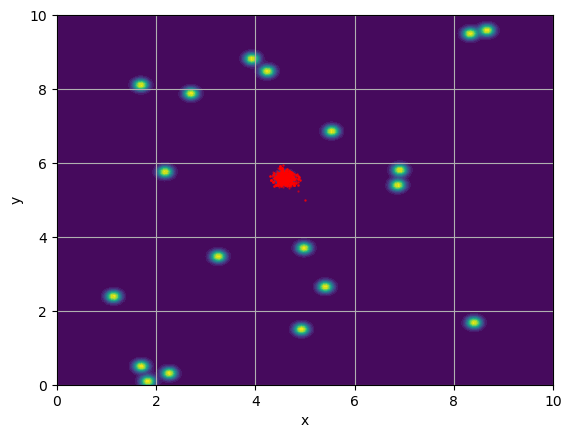

In [26]:
fig, ax = plt.subplots(1)
plot_MC_with_contour2(xs[:, 0], xs[:, 1], ax)

### 2.B : Parallel Tempering

>**Question 1 :** Comme le montre l'illustration suivante des distributions tempérées, plus la température est élevée, plus les modes s'élargisse et plus il devient possible pour la chaine de Markov de transitionner entre les modes. Ainsi pour $T_1$, une méthode de Metropolis-Hastings attendra plus rapidement son état stationnaire. 

In [27]:
def plot3D(ax, T):
    x = jnp.linspace(0, 10, 100)
    y= jnp.linspace(0,10, 100)
    X,Y = jnp.meshgrid(x,y)
    points = jnp.c_[X.ravel(), Y.ravel()]
    Z = jax.vmap(lambda x : pi(x)**(1/T))(points).reshape(X.shape)
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)

In [28]:
Ts = jnp.array([60., 21.5, 7.7, 2.8, 1.])

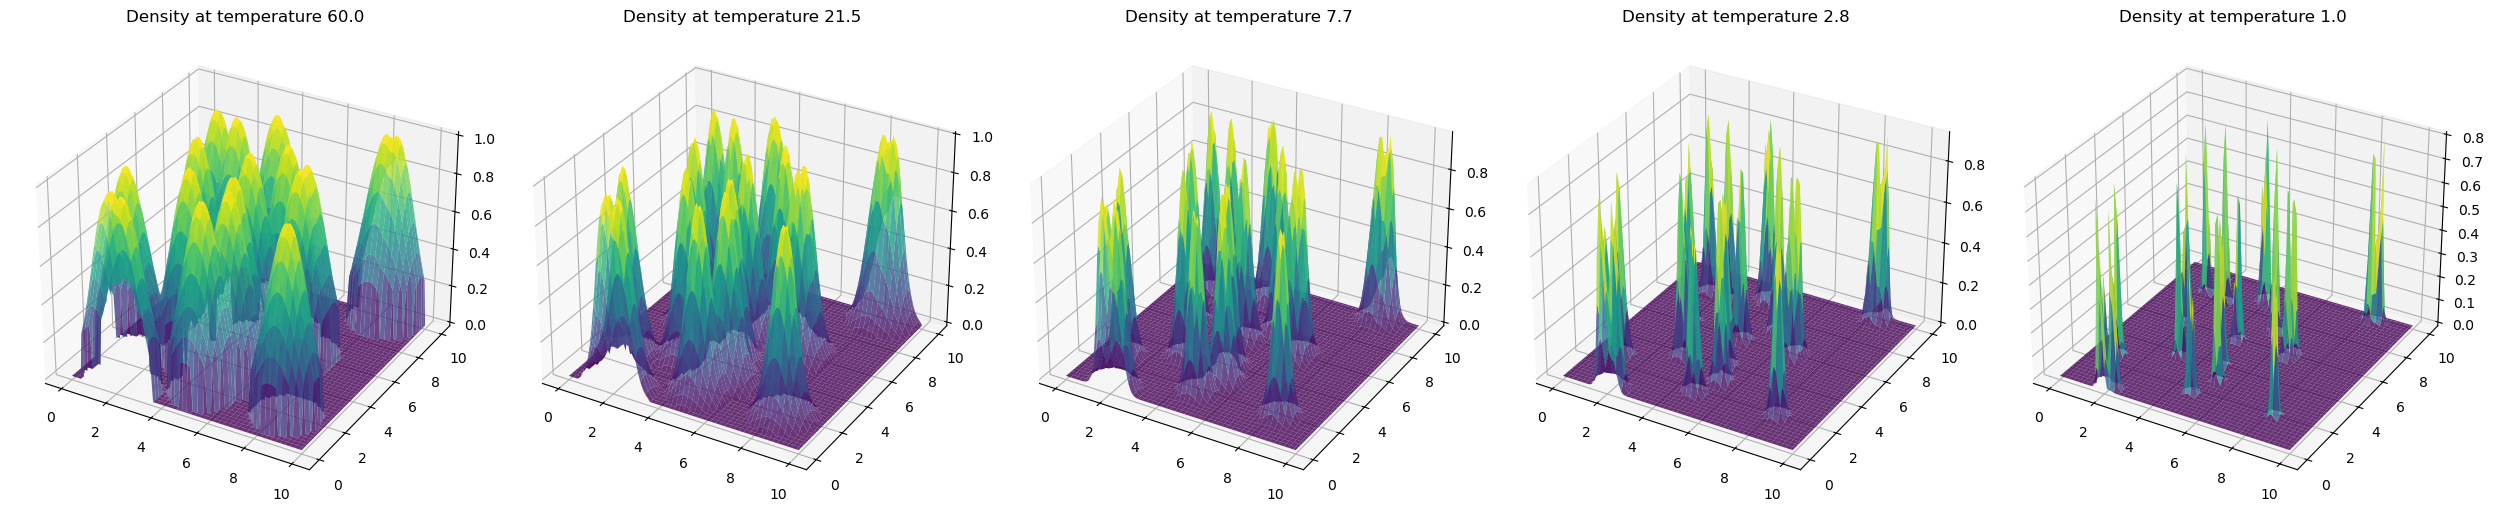

In [29]:
fig, axs = plt.subplots(1, 5, subplot_kw={'projection': '3d'}, figsize=(25, 5))

for i in range(5):
    T = Ts[i]
    plot3D(axs[i], T)
    axs[i].set_title(f"Density at temperature {T:.1f}")

fig.tight_layout()

>**Question 2 :** Dans cette question on implemente la méthode de Parallel Tempering. L'implémetation est en suite testée dans la question suivante. 

In [30]:
def parallel_tempering(key, xs0, Ts, n_iter):

    # Compute variance for MH step
    taus = jax.vmap(lambda T : 0.25*jnp.sqrt(T))(Ts)

    # Sample from MH transition kernel
    def MH_transition(key, x, tau, T):
        subkey1, subkey2 = jr.split(key)
        # Proposal
        x_prop = x + tau*jr.normal(subkey1, shape = (2,))
        # Accept-reject
        u = jr.uniform(subkey2)
        x, acc = jax.lax.cond(
            jnp.log(u)< 1/T*(log_pi(x_prop)-log_pi(x)),
            lambda : (x_prop, 1), 
            lambda : (x, 0)
        )
        return x, acc

    # One step of parallel tempering
    def pt_step(carry, key):
        xs = carry['xs']
        n_accs = carry["n_accs"]
        n_swap = carry["n_swap"]

        # Metropolis Hastings Kernel
        subkey1, subkey2, subkey3 = jr.split(key,3)
        keys = jr.split(subkey1, Ts.shape[0])
        ys, accs = jax.vmap(MH_transition)(keys, xs, taus, Ts)

        # Swap at random two ys 
        indices = jr.choice(subkey2, Ts.shape[0], shape = (2,), replace = False)
        i, j = indices[0], indices[1]
        u = jr.uniform(subkey3)
        cond_swap = jnp.log(u) < 1/Ts[i]*log_pi(ys[j]) + 1/Ts[j]*log_pi(ys[i])- 1/Ts[i]*log_pi(ys[i])-1/Ts[j]*log_pi(ys[j])
        xs, swap = jax.lax.cond(
            cond_swap,
            lambda : (ys.at[jnp.array([i, j])].set(ys[jnp.array([j, i])]), 1),
            lambda : (xs, 0)
        )

        # Make output
        carry = {
            "xs" : xs,
            "n_accs" : n_accs + accs,
            "n_swap" : n_swap + swap 
        }

        output = {
            "xs" : xs, 
        }
        return carry, output

    init = {
        "xs" : xs0,
        "n_accs" : jnp.zeros(Ts.shape[0]), 
        "n_swap" : 0 
    }
    keys = jr.split(key, n_iter)
    carry, outputs = jax.lax.scan(pt_step, init, keys)

    print("Parallel tempering performed with : \n")
    print(f"- Number of swaps : {carry["n_swap"]}")
    print(f"- Acceptance rates :  {carry["n_accs"]/ n_iter}")
    # The sampled value is the last element of the last chain
    return carry["xs"][Ts.shape[0]], outputs["xs"]        

>**Question 3:** On teste l'algorithme précédent sur le modèle de mixture de gaussiennes. On remarque sur l'illustration suivante que tous les modes sont parcourrus lors de l'échantilonnage, ce qui était l'effet estcompté.

In [31]:
key, subkey = jr.split(key)
xs0 = jnp.full((Ts.shape[0], 2), 5.0)
n_iter = 2000
Ts = Ts

x, chains = parallel_tempering(subkey, xs0, Ts, n_iter)
xs = chains[:, 4, :]

Parallel tempering performed with : 

- Number of swaps : 763
- Acceptance rates :  [0.468 0.383 0.289 0.263 0.288]


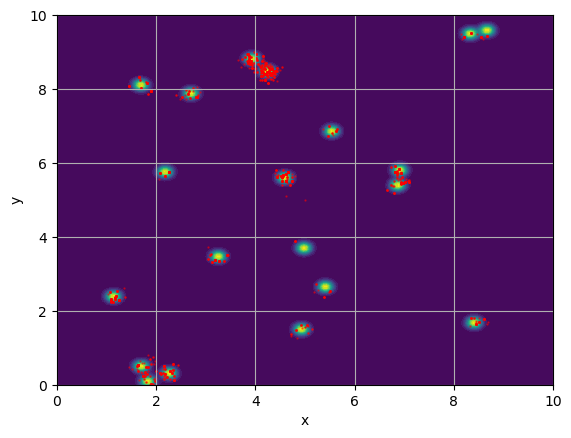

In [32]:
fig, ax = plt.subplots(1)
plot_MC_with_contour2(xs[:, 0], xs[:, 1], ax)

## **Exercice 3 :**